In [1]:
print("Hello Bro")

Hello Bro


In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
import plotly.express as px

In [6]:
from scipy.stats import linregress

In [9]:
nav = pd.read_csv("../data/raw/02_nav_history_cleaned.csv")
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [10]:
print(nav.shape)
print(nav.dtypes)

(46000, 3)
amfi_code      int64
date             str
nav          float64
dtype: object


In [11]:
nav['date']=pd.to_datetime(nav['date'])

In [12]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [14]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


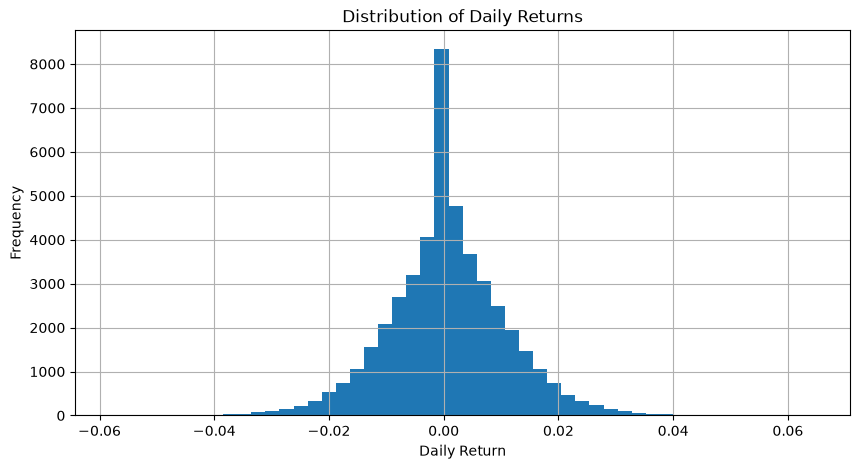

In [15]:
plt.figure(figsize=(10,5))

nav["daily_return"].hist(bins=50)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [22]:
   #TASK 2 — CAGR

latest_date = nav["date"].max()
print(latest_date)

2026-05-29 00:00:00


In [23]:
def calculate_cagr(df, years):
    target_date = latest_date - pd.DateOffset(years=years)

    results = []

    for fund in df["amfi_code"].unique():

        fund_data = df[df["amfi_code"] == fund].sort_values("date")

        end_nav = fund_data.iloc[-1]["nav"]

        start_data = fund_data[fund_data["date"] <= target_date]

        if start_data.empty:
            cagr = None
        else:
            start_nav = start_data.iloc[-1]["nav"]
            cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

        results.append([fund, cagr])

    return pd.DataFrame(results, columns=["amfi_code", f"{years}Y CAGR (%)"])

In [24]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)

In [25]:
cagr_5 = pd.DataFrame({
    "amfi_code": nav["amfi_code"].unique(),
    "5Y CAGR (%)": "N/A"
})

In [26]:
cagr_table = cagr_1.merge(cagr_3, on="amfi_code")
cagr_table = cagr_table.merge(cagr_5, on="amfi_code")

cagr_table.head()

,amfi_code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
0,100016,-2.224271,1.292649,N/A
1,100025,3.704969,3.916390,N/A
2,100033,53.232396,32.442459,N/A
3,101206,47.924120,28.967695,N/A
4,101207,-23.986032,-4.152381,N/A


In [ ]:
## CAGR Analysis

- Calculated 1-year and 3-year CAGR for all available mutual fund schemes.
- A complete 5-year CAGR could not be calculated because the dataset spans from January 2022 to May 2026 (approximately 4 years and 5 months), which is insufficient for a full 5-year analysis.

In [28]:
#Sharp ratio
risk_free = 0.065 / 252

In [29]:
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe["Sharpe Ratio"] = (
    (sharpe["mean"] - risk_free)
    /
    sharpe["std"]
) * np.sqrt(252)

In [30]:
sharpe = sharpe.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe.head(10)

,amfi_code,mean,std,Sharpe Ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


In [31]:
#Sortino Ratio
negative_returns = nav.copy()

negative_returns = negative_returns[
    negative_returns["daily_return"] < 0
]

In [32]:
downside_std = (
    negative_returns.groupby("amfi_code")["daily_return"]
    .std()
    .reset_index(name="downside_std")
)

In [34]:
mean_return = (
    nav.groupby("amfi_code")["daily_return"]
    .mean()
    .reset_index(name="mean_return")
)


sortino = mean_return.merge(
    downside_std,
    on="amfi_code"
)

In [35]:
sortino["Sortino Ratio"] = (
    (sortino["mean_return"] - risk_free)
    /
    sortino["downside_std"]
) * np.sqrt(252)

In [36]:
sortino = sortino.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino.head(10)

,amfi_code,mean_return,downside_std,Sortino Ratio
34,148567,0.001074,0.005428,2.385644
30,120843,0.001082,0.005531,2.364320
36,148569,0.001124,0.006404,2.146914
19,119551,0.000917,0.004887,2.140267
25,120505,0.001161,0.007067,2.029353
38,149323,0.001055,0.006750,1.875101
9,118632,0.000865,0.005211,1.850133
2,100033,0.001080,0.007133,1.829134
24,120504,0.000843,0.005145,1.805294
3,101206,0.000852,0.005238,1.799563


In [40]:
#Alpha & Beta
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
benchmark.columns
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [42]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [43]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [46]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

In [48]:
nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

In [50]:
merged = nav.merge(
    nifty100,
    on="date",
    how="inner"
)


results = []

for fund in merged["amfi_code"].unique():

    fund_data = merged[
        merged["amfi_code"] == fund
    ]

    slope, intercept, r_value, p_value, std_err = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    alpha = intercept * 252
    beta = slope

    results.append(
        [fund, alpha, beta]
    )

In [51]:
alpha_beta = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "Alpha",
        "Beta"
    ]
)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,NaN,NaN
1,100025,NaN,NaN
2,100033,NaN,NaN
3,101206,NaN,NaN
4,101207,NaN,NaN


In [53]:
alpha_beta.to_csv("../reports/alpha_beta.csv", index=False)

In [55]:
#Maximum Drawdown

nav["running_max"] = (
    nav.groupby("amfi_code")["nav"]
       .cummax()
)

nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

In [56]:
max_drawdown = (
    nav.groupby("amfi_code")["drawdown"]
       .min()
       .reset_index(name="Maximum Drawdown")
)

max_drawdown.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [57]:
max_drawdown.to_csv(
    "../reports/max_drawdown.csv",
    index=False
)

In [58]:
#SCORECARD
score = cagr_table.merge(sharpe, on="amfi_code")
score = score.merge(alpha_beta, on="amfi_code")
score = score.merge(max_drawdown, on="amfi_code")

In [59]:
#3Y CAGR rank
score["cagr_rank"] = score["3Y CAGR (%)"].rank(ascending=False)
#Sharpe rank
score["sharpe_rank"] = score["Sharpe Ratio"].rank(ascending=False)
#Alpha rank
score["alpha_rank"] = score["Alpha"].rank(ascending=False)
#Max Drawdown rank (IMPORTANT: lower is better)
score["dd_rank"] = score["Maximum Drawdown"].rank(ascending=True)

In [60]:
score.columns

Index(['amfi_code', '1Y CAGR (%)', '3Y CAGR (%)', '5Y CAGR (%)', 'mean', 'std',
       'Sharpe Ratio', 'Alpha', 'Beta', 'Maximum Drawdown', 'cagr_rank',
       'sharpe_rank', 'alpha_rank', 'dd_rank'],
      dtype='str')

In [62]:
expense = pd.read_csv("../data/raw/01_fund_master.csv")

In [63]:
expense.columns

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')

In [64]:
expense = expense[["amfi_code", "expense_ratio_pct"]]

In [65]:
score = score.merge(expense, on="amfi_code", how="left")

In [67]:
score.rename(columns={"expense_ratio_pct": "expense_ratio"}, inplace=True)
score["expense_rank"] = score["expense_ratio"].rank(ascending=True)

In [70]:
score["fund_score"] = (
    0.30 * score["cagr_rank"] +
    0.25 * score["sharpe_rank"] +
    0.20 * score["alpha_rank"] +
    0.15 * score["expense_rank"] +
    0.10 * score["dd_rank"]
)

score["fund_score"] = (
    (score["fund_score"].max() - score["fund_score"])
    / score["fund_score"].max()
) * 100

In [71]:
score.sort_values("fund_score", ascending=False).head(10)

,amfi_code,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%),mean,std,Sharpe Ratio,Alpha,Beta,Maximum Drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,expense_ratio,expense_rank,fund_score
0,100016,-2.224271,1.292649,N/A,0.000142,0.009164,-0.201517,NaN,NaN,-0.247344,35.0,35.0,NaN,7.0,1.55,32.0,NaN
1,100025,3.704969,3.916390,N/A,0.000170,0.002460,-0.567095,NaN,NaN,-0.043083,34.0,39.0,NaN,37.0,0.56,2.0,NaN
2,100033,53.232396,32.442459,N/A,0.001080,0.011929,1.093699,NaN,NaN,-0.162172,4.0,7.0,NaN,21.0,1.38,17.0,NaN
3,101206,47.924120,28.967695,N/A,0.000852,0.009177,1.027213,NaN,NaN,-0.112916,9.0,9.0,NaN,32.0,1.60,36.5,NaN
4,101207,-23.986032,-4.152381,N/A,0.000424,0.016251,0.162661,NaN,NaN,-0.354469,39.0,28.0,NaN,3.0,1.53,28.5,NaN
5,101208,7.236645,6.315784,N/A,0.000242,0.000319,-0.815567,NaN,NaN,-0.001622,31.0,40.0,NaN,38.0,0.79,11.0,NaN
6,102885,20.207704,19.667262,N/A,0.000674,0.008086,0.817099,NaN,NaN,-0.108599,18.0,16.0,NaN,34.0,1.57,34.0,NaN
7,102886,-16.797481,-0.767406,N/A,0.000110,0.011424,-0.205832,NaN,NaN,-0.280011,37.0,36.0,NaN,6.0,1.51,24.5,NaN
8,102887,13.583135,25.556188,N/A,0.000645,0.009927,0.619518,NaN,NaN,-0.215398,13.0,22.0,NaN,11.0,1.64,39.5,NaN
9,118632,33.981048,22.652360,N/A,0.000865,0.008913,1.081659,NaN,NaN,-0.174141,14.0,8.0,NaN,18.0,1.51,24.5,NaN


In [72]:
#Benchmark Comparison Chart (TOP 5 FUNDS vs MARKET)
top5 = score.sort_values("fund_score", ascending=False).head(5)
top_funds = top5["amfi_code"].tolist()

fund_returns = nav.copy()
fund_returns = fund_returns[fund_returns["amfi_code"].isin(top_funds)]

In [73]:
fund_returns["cum_return"] = fund_returns.groupby("amfi_code")["daily_return"].cumsum()
benchmark = benchmark[benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])]
benchmark["benchmark_return"] = benchmark.groupby("index_name")["close_value"].pct_change()
benchmark["cum_return"] = benchmark.groupby("index_name")["benchmark_return"].cumsum()

In [74]:
import plotly.express as px

fig = px.line(
    fund_returns,
    x="date",
    y="cum_return",
    color="amfi_code",
    title="Top 5 Funds vs Market Performance"
)

fig.show()